In [185]:
import os
import glob
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

### Data Import

In [2]:
DATA_DIR = "./analytics_data"

# Grab files for input, output
input_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/input_2023_w*.csv"))) # Pre-release of ball data
output_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/output_2023_w*.csv"))) # Post-release of ball data

# Put together all input, output data
input_data = pd.concat((pd.read_csv(p) for p in input_files), ignore_index=True)
output_data = pd.concat((pd.read_csv(p) for p in output_files), ignore_index = True)
sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/544402945.py:10: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")


In [8]:
# Merge input, output data with supplementary data on play_id
input_merged = input_data.merge(sup_data, on=['game_id', 'play_id'], how='left')
output_merged = input_data.merge(sup_data, on=['game_id', 'play_id'], how='left')

In [334]:
# Select Deep Passes as Plays of Interest
input_deep = input_merged.copy()
input_deep = input_deep[input_deep['pass_length'] > 19]
input_deep = input_deep.reset_index().drop('index', axis = 1)
input_deep['to_release'] = 'before'

output_deep = output_merged.copy()
output_deep = output_deep[output_deep['pass_length'] > 19]
output_deep = output_deep.reset_index().drop('index', axis = 1)
output_deep['to_release'] = 'after'

In [19]:
input_deep.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'season',
       'week', 'game_date', 'game_time_eastern', 'home_team_abbr',
       'visitor_team_abbr', 'play_description', 'quarter', 'game_clock',
       'down', 'yards_to_go', 'possession_team', 'defensive_team',
       'yardline_side', 'yardline_number', 'pre_snap_home_score',
       'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result',
       'pass_length', 'offense_formation', 'receiver_alignment',
       'route_of_targeted_receiver', 'play_action', 'dropback_type',
       'dropback_distance', 'pass_location_type', 'defenders_in_the_box',
       'team_coverage_man_zone', 'team_coverage_type', 'penalty_yards',
       'pre_

### Data Engineering

#### Make Wide Data

In [338]:
def make_wide_data(input_data, output_data):

    # Copy data
    in_df = input_data.copy()
    out_df = output_data.copy()

    # Ensure consistent data types for grouping
    in_df['game_id'] = in_df['game_id'].astype(int)
    in_df['play_id'] = in_df['play_id'].astype(int)
    out_df['game_id'] = out_df['game_id'].astype(int)
    out_df['play_id'] = out_df['play_id'].astype(int)

    # Create Global Frame_Id between input and output ============================

    # ---Create a lookup table, one row per play, of form |game_id|play_id|max_before_frame|
    max_before = (
        in_df.groupby(['game_id', 'play_id'])['frame_id'] # Group by game/play combo, take frame_id
             .max()                                       # Grab the max frame id within the play
             .rename('max_before_frame')                  # set column name output to max_before frame
             .reset_index()
    )

    # ---Join max_before with out_df, so we can use max_before_frame to increment
    #    and make global frame id
    out_df = out_df.merge(max_before, on=['game_id', 'play_id'], how='left')
    out_df['max_before_frame'] = out_df['max_before_frame'].fillna(0).astype(int)

    # ---Establish 'frame_global' variable for both dataframes
    in_df = in_df.assign(frame_global = in_df['frame_id'].astype(int))
    out_df = out_df.assign(frame_global = out_df['frame_id'].astype(int) + out_df['max_before_frame'].astype(int))

    # ---Combine in and out dataframes into one
    combined = pd.concat([in_df, out_df], ignore_index = True, sort = False)


    
    # Build dataframe for receiver ==============================================
    '''
        Grab frames for receivers, rename their columns, create list of base
        columns for all frames, and set up target receiver distance to ball
        and complete variables
    '''
    rec = combined[combined['player_role'] == 'Targeted Receiver'].copy()

    # ---Rename receiver columns to tgt_rec_*
    rec = rec.rename(columns={
        'player_name': 'tgt_rec_name',
        'x': 'tgt_rec_x',
        'y': 'tgt_rec_y',
        's': 'tgt_rec_s',
        'a': 'tgt_rec_a',
        'o': 'tgt_rec_o',
        'dir': 'tgt_rec_dir',
        'pass_result': 'pass_result'  # keep same name
    })

    # ---Create list of columns that stay exactly the same for every row in wide df ("base index")
    base_cols = [
        # Game Metadata
        'game_id', 'home_team_abbr', 'visitor_team_abbr',
        # Play Metadata
        'play_id', 'play_description', 'quarter', 'game_clock', 'down',
        'yards_to_go', 'yardline_side', 'yardline_number', 'possession_team',
        'pre_snap_home_score', 'pre_snap_visitor_score',
        # Play Data
        'pass_length', 'pass_result', 'offense_formation', 'receiver_alignment',
        'ball_land_x', 'ball_land_y', 'route_of_targeted_receiver',
        'pass_location_type', 'team_coverage_man_zone', 'team_coverage_type',
        'yards_gained',
        # Frame Data
        'frame_id', 'frame_global', 'to_release',
        # tgt_rec_*
        'tgt_rec_name', 'tgt_rec_x', 'tgt_rec_y', 'tgt_rec_s', 'tgt_rec_a',
        'tgt_rec_o', 'tgt_rec_dir'
    ]

    # ---Create dataframe of base columns only
    base = rec[base_cols].copy()

    # ---Compute derived receiver fields (ball_dist, complete)
    base['tgt_rec_ball_dist'] = np.hypot(base['tgt_rec_x'] - base['ball_land_x'], base['tgt_rec_y'] - base['ball_land_y'])
    base['complete'] = (base['pass_result'] == 'C').astype(int)



    # Build dataframe for defenders and merge with receiver info ================
    '''
        Grab frames for defenders, add base metadata to the frames, and compute
        distance to receiver and distance to ball for each frame
    '''
    defs = combined[combined['player_role'] == 'Defensive Coverage'].copy()

    # ---Select required defender columns
    def_cols = ['game_id','play_id','frame_id','frame_global','to_release','player_name','x','y','s','a','o','dir','ball_land_x','ball_land_y']
    defs = defs[def_cols].copy()

    # ---Merge defender rows with corresponding receiver row (to compute distances)
    defs = defs.merge(
        base[['game_id','play_id','frame_id','tgt_rec_x','tgt_rec_y','ball_land_x','ball_land_y']],
        on=['game_id','play_id','frame_id'],
        how='left',
        suffixes=('', '_tgt')
    )

    # ---Compute per-frame distances (vectorized)
    defs['dist_to_rec'] = np.hypot(defs['x'] - defs['tgt_rec_x'], defs['y'] - defs['tgt_rec_y'])
    defs['dist_to_ball'] = np.hypot(defs['x'] - defs['ball_land_x'], defs['y'] - defs['ball_land_y'])



    # Compute 4 closest defenders at release =====================================
    '''
        For each game/play combo, create a table that indicate each defender's 'slot',
        i.e. their ranking in closesness to the receiver at ball release.

        1) Get release frames for each play
        2) Select only defender frames for release frames
        3) Merge in receiver location for each release frame for defenders to calculate distances
        4) Compute distance to receiver for each defender on release frames
        5) For each play, grab only 4 closest defenders to rec at release
        6) Assign slot to each defender for each game/play ranked by dist from rec at release
    '''

    # ---Find release frame for each play
    release_frames = out_df[out_df['to_release'] == 'after'].groupby(['game_id','play_id'])['frame_id'].min().rename('release_frame').reset_index()

    # ---Get release frames only by merging release_frame with out_df
    out_with_release = out_df.merge(release_frames, on=['game_id','play_id'], how='left')

    # ---Select rows that are defenders at release frame
    release_defs = out_with_release[
        (out_with_release['player_role'] == 'Defensive Coverage') &
        (out_with_release['frame_id'] == out_with_release['release_frame'])
    ].copy()

    # ---Merge receiver info for location information at release frame
    #    After this, release_rec contains one row per play, in the form
    #    | game_id | play_id | frame_id | tgt_rec_x / y | ball_land_x / y |
    release_rec = rec.merge(release_frames, on=['game_id','play_id'], how='right')
    release_rec = release_rec[release_rec['frame_id'] == release_rec['release_frame']][['game_id','play_id','frame_id','tgt_rec_x','tgt_rec_y','ball_land_x','ball_land_y']]

    # ---Merge receiver/ball loc info into release frame defender rows
    release_defs = release_defs.merge(
        release_rec,
        on=['game_id','play_id','frame_id'],
        how='left'
    )

    # ---Compute distance to receiver for each defender if possible
    if not release_defs.empty:
        release_defs['dist_to_rec'] = np.hypot(release_defs['x'] - release_defs['tgt_rec_x'], release_defs['y'] - release_defs['tgt_rec_y'])
    else:
        # If no release_defs found, create empty DataFrame with expected cols
        release_defs = pd.DataFrame(columns=list(defs.columns) + ['dist_to_rec'])

    # ---For each play, pick up to 4 closest defenders at release (create table)
    #    | game_id | play_id | dist_to_rec | player_name |
    release_closest4 = (
        release_defs
            .sort_values(['game_id','play_id','dist_to_rec'])
            .groupby(['game_id','play_id'], group_keys=False)
            .head(4)
            .copy()
    )

    # ---Assign slot (def_1...def_4) per play based on order (1 = closest at release)
    #    | game_id | play_id | player_name | slot |
    if not release_closest4.empty:
        release_closest4['slot'] = (
            release_closest4.groupby(['game_id','play_id'])['dist_to_rec']
                          .rank(method='first').astype(int)
        )
        # Keep mapping: game_id, play_id, player_name -> slot
        slot_map = release_closest4[['game_id','play_id','player_name','slot']].copy()
    else:
        slot_map = pd.DataFrame(columns=['game_id','play_id','player_name','slot'])



    # Create def_N_ via pivot by slot_map merge =====================================
    '''
        Creating a wide dataframe for def_N, where for each game/play/frame combo,
        we have def_{N}_{stat} columns

        1) To defender frames, merge slot_map, which indicates the 'slot' that each
           defender is (a ranking of how close they were to rec at ball release
        2) Define pivot_stats, which is a mapping of the stats that will be used
           as columns in the wide dataframe
        3) Drop defenders without a slot, only keeping the 4 closest defenders at release
        4) Create a wide df for each stat
        5) Combine wide df's for each stat into one big one for each game/play/frame
           containing cols of all def_{N}_{stat}'s as columns
    '''

    # ---Merge slot_map to defender frames so we have ranking of defenders at ball release on def data
    defs_with_slot = defs.merge(slot_map, on=['game_id','play_id','player_name'], how='left')

    # ---Build map: Keys: Stat Names in row form, Values: suffix used for 'wide' column form
    pivot_stats = {
        'player_name': 'name',
        'x': 'x',
        'y': 'y',
        's': 's',
        'a': 'a',
        'o': 'o',
        'dir': 'dir',
        'dist_to_rec': 'dist',
        'dist_to_ball': 'ball_dist'
    }

    # ---Keep only rows that have slot assigned (these correspond to the 4 chosen at release)
    defs_slot_only = defs_with_slot.dropna(subset=['slot']).copy()
    
    # ---Ensure slot is integer
    defs_slot_only['slot'] = defs_slot_only['slot'].astype(int)

    # ---Pivot each stat into wide columns def_{slot}_{stat}
    # ---For each stat in pivot_stats, we pivot to create a table like
    # | game_id | play_id | frame_id | frame_global | to_release | slot = 1 | ... | slot = 4 |
    #     ...      ...         ...         ...           ...       def_1_{stat}   def_4_{stat}
    defN_wide_frames = []
    if not defs_slot_only.empty:
        for src_col, dst_suffix in pivot_stats.items():
            tmp = defs_slot_only.pivot_table(
                index=['game_id','play_id','frame_id','frame_global','to_release'],
                columns='slot',
                values=src_col,
                aggfunc='first'
            )
            # rename pivoted columns to final names: def_N_{stat}
            tmp_cols = {}
            for col in tmp.columns:
                tmp_cols[col] = f'def_{int(col)}_{dst_suffix}'
            tmp = tmp.rename(columns=tmp_cols)
            # Reset index so we can merge later
            tmp = tmp.reset_index()
            defN_wide_frames.append(tmp)

    # ---Merge all def_N_{stat} wide tables together into one wide table
    if defN_wide_frames:
        from functools import reduce
        defN_wide = reduce(lambda left, right: pd.merge(left, right, on=['game_id','play_id','frame_id','frame_global','to_release'], how='outer'), defN_wide_frames)
    else:
        # Empty placeholder
        defN_wide = pd.DataFrame(columns=['game_id','play_id','frame_id','frame_global','to_release'])



    # Compute def_closeN_ ==========================================================
    '''
        Creating a wide dataframe for def_closeN, where for each game/play/frame combo,
        we have def_close{N}_{stat} columns

        1) For each game/play/frame, get the closest 4 defenders and their metrics
        2) Assign 'rank' to defenders based on closeness to receiver at this frame
        3) Create a wide df for each stat
        4) Combine wide df's for each stat into one big one for each game/play/frame
           containing cols of all def_close{N}_{stat}'s as columns
    '''

    # ---For each defender game/play/frame combo, rank defenders by dist_to_rec and take up to 4
    # | game_id | play_id | frame_id | player_name | dist_to_rec (sorted) | x | y | ... |
    close_sorted = (
        defs.sort_values(['game_id','play_id','frame_id','dist_to_rec'])
            .groupby(['game_id','play_id','frame_id'], group_keys=False)
            .head(4)
            .copy()
    )

    # ---Assign rank of closeness (1...4) to defender per frame
    # | game_id | play_id | frame_id | rank | ...
    close_sorted['rank'] = close_sorted.groupby(['game_id','play_id','frame_id']).cumcount() + 1

    # ---Pivot each stat into wide columns def_{rank}_{stat}
    # ---For each stat in pivot_stats, we pivot to create a table like
    # | game_id | play_id | frame_id | frame_global | to_release | rank = 1 | ... | rank = 4 |
    #     ...      ...         ...         ...           ...  def_close1_{stat}   def_close4_{stat}
    defclose_wide_frames = []
    for src_col, dst_suffix in pivot_stats.items():
        tmp = close_sorted.pivot_table(
            index=['game_id','play_id','frame_id','frame_global','to_release'],
            columns='rank',
            values=src_col,
            aggfunc='first'
        )
        # rename pivoted columns to final names: def_closeN_{stat}
        tmp_cols = {}
        for col in tmp.columns:
            tmp_cols[col] = f'def_close{int(col)}_{dst_suffix}'
        tmp = tmp.rename(columns=tmp_cols).reset_index()
        defclose_wide_frames.append(tmp)

    # ---Merge all def_closeN_{stat} wide tables together into one wide table
    if defclose_wide_frames:
        defclose_wide = reduce(lambda left, right: pd.merge(left, right, on=['game_id','play_id','frame_id','frame_global','to_release'], how='outer'), defclose_wide_frames)
    else:
        defclose_wide = pd.DataFrame(columns=['game_id','play_id','frame_id','frame_global','to_release'])



    # Build final wide DataFrame by merging base rec rows with def_N and def_closeN ============
    '''
        Final Cleanup Stage
        1) Combine base metadata with def_N and def_closeN wide dataframes
           on 'base_index', which uniquely identifies a frame in wide dfs
        2) Build lists of expected columns for def_N and def_closeN, add in NaN's
           where we have missing columns
        3) Ensure that all distance column values are numeric
        4) Reorder columns to put base level metadata first
    '''

    # ---columns that uniquely identify a single frame in each wide dataset
    base_index = ['game_id','play_id','frame_id','frame_global','to_release']

    # ---Merge defN_wide and defclose_wide to base (play level metadata) to make final wide df
    wide = base.reset_index(drop=True).merge(defN_wide, on=base_index, how='left').merge(defclose_wide, on=base_index, how='left')

    # ---Build list of expected def_N column names for consistency
    expected_defN_cols = []
    for i in range(1,5):
        for suffix in pivot_stats.values():
            expected_defN_cols.append(f'def_{i}_{suffix}')

    # ---Build list of expected def_closeN column names for consistency
    expected_defclose_cols = []
    for i in range(1,5):
        for suffix in pivot_stats.values():
            expected_defclose_cols.append(f'def_close{i}_{suffix}')

    # ---Add missing columns to wide just in case
    for c in expected_defN_cols + expected_defclose_cols:
        if c not in wide.columns:
            wide[c] = np.nan

    # ---Ensure all distance columns are numeric
    for i in range(1,5):
        wide[f'def_close{i}_dist'] = pd.to_numeric(wide[f'def_close{i}_dist'], errors='coerce')
        wide[f'def_close{i}_ball_dist'] = pd.to_numeric(wide[f'def_close{i}_ball_dist'], errors='coerce')
        wide[f'def_{i}_dist'] = pd.to_numeric(wide[f'def_{i}_dist'], errors='coerce')
        wide[f'def_{i}_ball_dist'] = pd.to_numeric(wide[f'def_{i}_ball_dist'], errors='coerce')

    # ---Reorder columns: put base columns first
    ordered_cols = base_index + [c for c in wide.columns if c not in base_index]
    wide = wide[ordered_cols]

    return wide

In [339]:
wide_data = make_wide_data(input_deep, output_deep)

In [341]:
wide_data.to_csv('wide_data.csv', index=False)

In [342]:
filt = wide_data[(wide_data['game_id'] == 2023090700) & (wide_data['play_id'] == 1679)][['game_id', 'play_id', 'frame_id', 'frame_global', 'to_release']]
filt.head(60)

,game_id,play_id,frame_id,frame_global,to_release
146,2023090700,1679,1,1,before
147,2023090700,1679,2,2,before
148,2023090700,1679,3,3,before
149,2023090700,1679,4,4,before
150,2023090700,1679,5,5,before
151,2023090700,1679,6,6,before
152,2023090700,1679,7,7,before
153,2023090700,1679,8,8,before
154,2023090700,1679,9,9,before
155,2023090700,1679,10,10,before


#### Load Wide Data

In [343]:
wide_data = pd.read_csv('wide_data.csv')

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/1903382724.py:1: DtypeWarning: Columns (73,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  wide_data = pd.read_csv('wide_data.csv')


In [345]:
list(wide_data.columns)

['game_id',
 'play_id',
 'frame_id',
 'frame_global',
 'to_release',
 'home_team_abbr',
 'visitor_team_abbr',
 'play_description',
 'quarter',
 'game_clock',
 'down',
 'yards_to_go',
 'yardline_side',
 'yardline_number',
 'possession_team',
 'pre_snap_home_score',
 'pre_snap_visitor_score',
 'pass_length',
 'pass_result',
 'offense_formation',
 'receiver_alignment',
 'ball_land_x',
 'ball_land_y',
 'route_of_targeted_receiver',
 'pass_location_type',
 'team_coverage_man_zone',
 'team_coverage_type',
 'yards_gained',
 'tgt_rec_name',
 'tgt_rec_x',
 'tgt_rec_y',
 'tgt_rec_s',
 'tgt_rec_a',
 'tgt_rec_o',
 'tgt_rec_dir',
 'tgt_rec_ball_dist',
 'complete',
 'def_1_name',
 'def_2_name',
 'def_3_name',
 'def_4_name',
 'def_1_x',
 'def_2_x',
 'def_3_x',
 'def_4_x',
 'def_1_y',
 'def_2_y',
 'def_3_y',
 'def_4_y',
 'def_1_s',
 'def_2_s',
 'def_3_s',
 'def_4_s',
 'def_1_a',
 'def_2_a',
 'def_3_a',
 'def_4_a',
 'def_1_o',
 'def_2_o',
 'def_3_o',
 'def_4_o',
 'def_1_dir',
 'def_2_dir',
 'def_3_dir'

#### Add Advanced Features

In [301]:
def add_advanced_features(df):
    df = df.copy();
    dt = 0.1 # one frame per 1/10th second

    # Add Ball Flight Alignment and Frame Alignment Features =====

    df['frames_till_event'] = np.nan
    df['flight_normalized_time'] = np.nan

    for (gid, pid), g in df.groupby(['game_id', 'play_id']):
        
        idxs = g.index.to_list()

        arrival_frame = g['frame_id'].max()

        # Frames Until Event (Play timing alignment with final frame)
        df.loc[idxs, 'frames_till_event'] = arrival_frame - g['frame_id']

        # Flight Normalized Time (Progression of Play after Release Proportionally)
        after_mask = (g['to_release'] == 'after')

        if after_mask.any():
            release_frame = g.loc[after_mask, 'frame_id'].min()
            flight_time = arrival_frame - release_frame

            if flight_time < 1:
                df.loc[idxs, 'flight_normalized_time'] = 0.0
            else:
                df.loc[idxs, 'flight_normalized_time'] = ((g['frame_id'] - release_frame) / flight_time).clip(0, 1)
        else:
            df.loc[idxs, 'flight_normalized_time'] = 0.0
    

    # Theta, Velocity Components =================================
    # Receiver: Theta, Velocity Components
    theta = np.deg2rad(df['tgt_rec_dir'])
    df['tgt_rec_vx'] = df['tgt_rec_s'] * np.cos(theta)
    df['tgt_rec_vy'] = df['tgt_rec_s'] * np.sin(theta)

    # Defenders: Theta, Velocity Components
    for n in range(1, 5):
        th = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_vx'] = df[f'def_{n}_s'] * np.cos(th)
        df[f'def_{n}_vy'] = df[f'def_{n}_s'] * np.sin(th)
        

    # Unit Vector to Ball (Receiver and Defenders) ===============
    def compute_u_ball(prefix):
        ux = df['ball_land_x'] - df[f'{prefix}_x']
        uy = df['ball_land_y'] - df[f'{prefix}_y']
        dist = np.hypot(ux, uy)
        dist[dist == 0] = 1e-9
        df[f'{prefix}_u_ball_x'] = ux / dist
        df[f'{prefix}_u_ball_y'] = uy / dist
        df[f'{prefix}_ball_dist'] = dist

    compute_u_ball("tgt_rec")
    for n in range(1, 5):
        compute_u_ball(f"def_{n}")



    # Velocity Toward Ball =======================================
    # Receiver Velocity Toward Ball
    df['tgt_rec_v_toward_ball'] = (
        df['tgt_rec_vx'] * df['tgt_rec_u_ball_x'] +
        df['tgt_rec_vy'] * df['tgt_rec_u_ball_y']
    )

    # Defenders Velocity Toward Ball
    for n in range(1, 5):
        df[f'def_{n}_v_toward_ball'] = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )


    # Closing Speed to Ball (pos = closing) =======================
    # Receiver Closing Speed to Ball
    df['tgt_rec_closing_speed_ball'] = (
        df.groupby(['game_id','play_id'])['tgt_rec_ball_dist'].diff(1) / dt
    )

    # Defenders Closingn Speed to Ball
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_ball'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_ball_dist'].diff(1) / dt
        )

    # Closing Speed Ball Advantage ================================
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_ball_adv'] = (
            df['tgt_rec_closing_speed_ball'] - df[f'def_{n}_closing_speed_ball']
        )

    
    # Momentum Advantage: Receiver vs. Defender ===================
    for n in range(1, 5):
        df[f'def_{n}_momentum_adv'] = (
            df['tgt_rec_v_toward_ball'] - df[f'def_{n}_v_toward_ball']
        )

    
    # Closing Speed: Defender to Receiver =========================
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_rec'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_dist'].diff(1) / dt
        )

    
    # MIN & MEAN Separation: All Defenders ========================
    dmat = df[[f'def_{i}_dist' for i in range(1, 5)]].values
    df['min_separation_all_def'] = np.min(dmat, axis=1)
    df['mean_separation_closest_3_defs'] = np.sort(dmat, axis=1)[:, :3].mean(axis=1)

    
    # Angle Defender Motion vs. Receiver Motion ===================
    rec_speed_mag = np.hypot(df['tgt_rec_vx'], df['tgt_rec_vy'])

    for n in range(1, 5):
        dot = df[f'def_{n}_vx'] * df['tgt_rec_vx'] + df[f'def_{n}_vy'] * df['tgt_rec_vy']
        den = (
            np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']) *
            rec_speed_mag
        ).clip(1e-8)
        df[f'def_{n}_angle_rec_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Angle Defender Motion vs. Ball Direction ===================
    for n in range(1, 5):
        dot = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )
        den = np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']).clip(1e-8)
        df[f'def_{n}_angle_ball_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Time to Ball: Receiver and Defenders =======================
    # Time to Ball - Receiver
    eps = 1e-6
    df['tgt_rec_t_to_ball'] = df['tgt_rec_ball_dist'] / df['tgt_rec_s'].clip(lower=eps)

    # Time to Ball - Defenders
    for n in range(1, 5):
        df[f'def_{n}_t_to_ball'] = (
            df[f'def_{n}_ball_dist'] / df[f'def_{n}_s'].clip(lower=eps)
        )

    df['min_t_def_to_ball'] = df[[f'def_{n}_t_to_ball' for n in range(1,5)]].min(axis=1)
    df['min_t_def_minus_t_rec'] = df['min_t_def_to_ball'] - df['tgt_rec_t_to_ball']


    # Crowdedness =================================================
    eps = 1e-3
    dist_cols = [f'def_{n}_dist' for n in range(1, 5)]
    df['crowdedness'] = (1.0 / (df[dist_cols] + eps)).sum(axis=1)


    # Acceleration Toward Ball - Receiver =========================
    th = np.deg2rad(df['tgt_rec_dir'])
    ax = df['tgt_rec_a'] * np.cos(th)
    ay = df['tgt_rec_a'] * np.sin(th)

    df['tgt_rec_a_toward_ball'] = (
        ax * df['tgt_rec_u_ball_x'] +
        ay * df['tgt_rec_u_ball_y']
    )


    # Defender In Phase ===========================================
    rec_dir_rad = np.deg2rad(df['tgt_rec_dir'])

    for n in range(1, 5):
        def_dir_rad = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_in_phase'] = np.cos(def_dir_rad - rec_dir_rad)


    # Angle Between Closest Two Defenders to Receiver =============

    # Compute Vectors from Receiver to each defender, distances
    for n in range(1, 5):
        df[f"dx_def{n}"] = df[f"def_{n}_x"] - df["tgt_rec_x"]
        df[f"dy_def{n}"] = df[f"def_{n}_y"] - df["tgt_rec_y"]
        df[f"dist_def{n}"] = np.hypot(df[f"dx_def{n}"], df[f"dy_def{n}"])

    # Identify Closest 2 Defenders
    dist_cols = ['dist_def1', 'dist_def2', 'dist_def3', 'dist_def4']
    dx_cols   = ['dx_def1', 'dx_def2', 'dx_def3', 'dx_def4']
    dy_cols   = ['dy_def1', 'dy_def2', 'dy_def3', 'dy_def4']

    closest_defenders_angles = []

    for i in range(len(df)):
        # Get distances for each defender for current frame
        d1 = df['dist_def1'].iat[i]
        d2 = df['dist_def2'].iat[i]
        d3 = df['dist_def3'].iat[i]
        d4 = df['dist_def4'].iat[i]

        dists = [d1, d2, d3, d4]

        # Get indicies of closest 2 defenders
        first_idx = dists.index(min(dists))

        rem_indices = [0, 1, 2, 3]
        rem_indices.remove(first_idx)
        rem_dists = [dists[j] for j in rem_indices]
        second_idx = rem_indices[rem_dists.index(min(rem_dists))]

        # Get dx, dy for two closest defenders
        dx_list = [df['dx_def1'].iat[i], df['dx_def2'].iat[i], df['dx_def3'].iat[i], df['dx_def4'].iat[i]]
        dy_list = [df['dy_def1'].iat[i], df['dy_def2'].iat[i], df['dy_def3'].iat[i], df['dy_def4'].iat[i]]

        dx1 = dx_list[first_idx]
        dy1 = dy_list[first_idx]
        dx2 = dx_list[second_idx]
        dy2 = dy_list[second_idx]

        # Compute angle between two vectors
        dot = dx1 * dx2 + dy1 * dy2
        mag1 = np.hypot(dx1, dy1)
        mag2 = np.hypot(dx2, dy2)
        denom = max(mag1 * mag2, 1e-9)
        cos_angle = np.clip(dot / denom, -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))

        closest_defenders_angles.append(angle_deg)

    df['closest_2_def_angle_diff'] = closest_defenders_angles


    # Rank defenders per frame by distance to receiver and create def_close features =================

    # Create global frame index
    df['frame_global'] = (
        df.groupby(['game_id','play_id'])
          .cumcount()
    )

    # Fix NaN's causing distortions
    dist_cols = [f'def_{i}_dist' for i in range(1,5)]
    df[dist_cols] = df[dist_cols].fillna(1e9)

    # List of stats belonging to each defender (suffix only)
    defender_stat_suffixes = [
        'dist',
        'ball_dist',
        'v_toward_ball',
        'closing_speed_ball',
        'closing_speed_ball_adv',
        'closing_speed_rec',
        't_to_ball',
        'momentum_adv',
        'angle_rec_deg',
        'angle_ball_deg',
        'in_phase',
        'vx',
        'vy'
    ]

    num_defenders = 4
    group_cols = ['game_id', 'play_id', 'frame_global']

    def rank_defenders_for_group(g):
        # use just one row — we know grouping is correct
        row = g.iloc[0]

        # rank order based on distances
        dists = np.array([row[f'def_{i}_dist'] for i in range(1, num_defenders+1)])
        order = np.argsort(dists)

        out = {}

        for stat in defender_stat_suffixes:
            values = np.array([row[f'def_{i}_{stat}'] for i in range(1, num_defenders+1)])
            sorted_values = values[order]

            for k in range(num_defenders):
                out[f'def_close{k+1}_{stat}'] = sorted_values[k]

        return pd.Series(out)

    ranked = (
        df.groupby(group_cols, group_keys = False)
          .apply(rank_defenders_for_group)
          .reset_index()
    )
    
    df = df.merge(ranked, on=group_cols, how='left')

    return df

In [302]:
data_adv = add_advanced_features(wide_data)

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_4271/871901159.py:290: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rank_defenders_for_group)


In [298]:
data_adv.to_csv('data_adv.csv', index=False)

In [292]:
data_adv = pd.read_csv('data_adv.csv')

In [303]:
data_adv[['def_1_vx', 'def_close1_vx']].corr()

,def_1_vx,def_close1_vx
def_1_vx,1.0,1.0
def_close1_vx,1.0,1.0


#### EDA Functions

In [186]:
def make_time_plot(df, y_col, route_type, nbins = 100, smooth_frac = 0.1):

    # Filter by route
    d = df[df['route_of_targeted_receiver'] == route_type].copy()

    # Filter to after release only
    d = d[d['to_release'] == 'after']

    # Bin times into groups
    d['time_bin'] = pd.cut(
        d['flight_normalized_time'],
        bins = np.linspace(0, 1, nbins+1),
        include_lowest=True
    )

    # Make dataframe of summary statistics per bin
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        summary = (
            d.groupby(['complete', 'time_bin'])
             .agg(
                 time_center = ('flight_normalized_time', 'mean'),
                 mean_y = (y_col, 'mean'),
                 q25 = (y_col, lambda x: np.percentile(x, 25)),
                 q75 = (y_col, lambda x: np.percentile(x, 75)),
                 count = (y_col, 'size')
             )
            .dropna()
            .reset_index()
        )

    # Initialize Plot
    plt.figure(figsize=(10, 6))

    colors = {0: '#1f77b4', 1: '#ff7f0e'} # Incomplete / Complete Colors

    for comp_status in [0, 1]:
        temp = summary[summary['complete'] == comp_status].copy()

        sm_mean = lowess(temp['mean_y'], temp['time_center'], frac=smooth_frac, return_sorted=True)
        sm_q25  = lowess(temp['q25'],    temp['time_center'], frac=smooth_frac, return_sorted=True)
        sm_q75  = lowess(temp['q75'],    temp['time_center'], frac=smooth_frac, return_sorted=True)

        x = sm_mean[:, 0]
        y = sm_mean[:, 1]
        y25 = sm_q25[:, 1]
        y75 = sm_q75[:, 1]

        label = "Complete" if comp_status == 1 else "Incomplete"

        # Plot band
        plt.fill_between(x, y25, y75, alpha=0.20, color=colors[comp_status])

        # Plot smoothed mean
        plt.plot(x, y, color=colors[comp_status], linewidth=2.5, label=label)

    plt.title(f"{y_col} vs Flight Normalized Time\nRoute: {route_type}", fontsize=16)
    plt.xlabel("Flight Normalized Time (0=release, 1=arrival)", fontsize=13)
    plt.ylabel(y_col, fontsize=13)
    plt.xlim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Exploratory Data Analysis

### dist
How close is a defender to the targeted receiver?

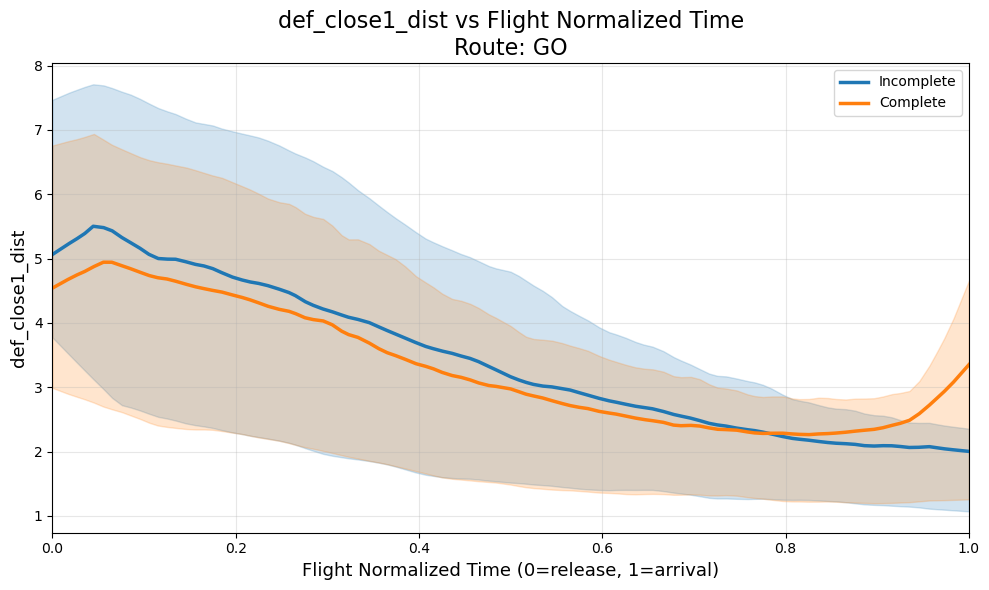

In [219]:
make_time_plot(data_adv, "def_close1_dist", route_type = "GO")

Remarks:
* In analyzing closest defender distance to receiver, we see the following:
  * GO: Kinda distinct separation from 0.8 on
  * POST: Pretty distinct separation from 0.75 on
  * CORNER: Not tons of separation, but fair amount starting from around 0.5
  * CROSS: Some amount from 0.6 on
  * IN: Solid amount from 0.4 on
  * HITCH: Small amount of sep 0.85 on
  * OUT: Decreasing separation over time, complete always more sep by a little
  * WHEEL: Weird, less separation indicates completion from 0.35 on
  * SLANT: Crossing behavior, on completion, see less separation until inflection point at 0.8, where goes to more separation by a lot... likely a good predictor here!
  * FLAT: Not getting band for completion, but complete is lower dist than incomplete
  * SCREEN: No complete data

Future Investigation:
* Can we dig in more to the last 0.2 of the route, and create more features with it? I.e. average separation last 20?

#### ball_dist
How far away is a player from the ball landing point?

In [ ]:
# EDA goes here

Remarks:
* None

Future Investigation:
* Should we add an advantage metric here?

#### momentum_adv
The difference between targeted receiver's velocity toward the ball and a defender's velocity toward the ball. Therefore, positive indicates the receiver has an advantage at a particular time, negative indicates an advantage for the defender.

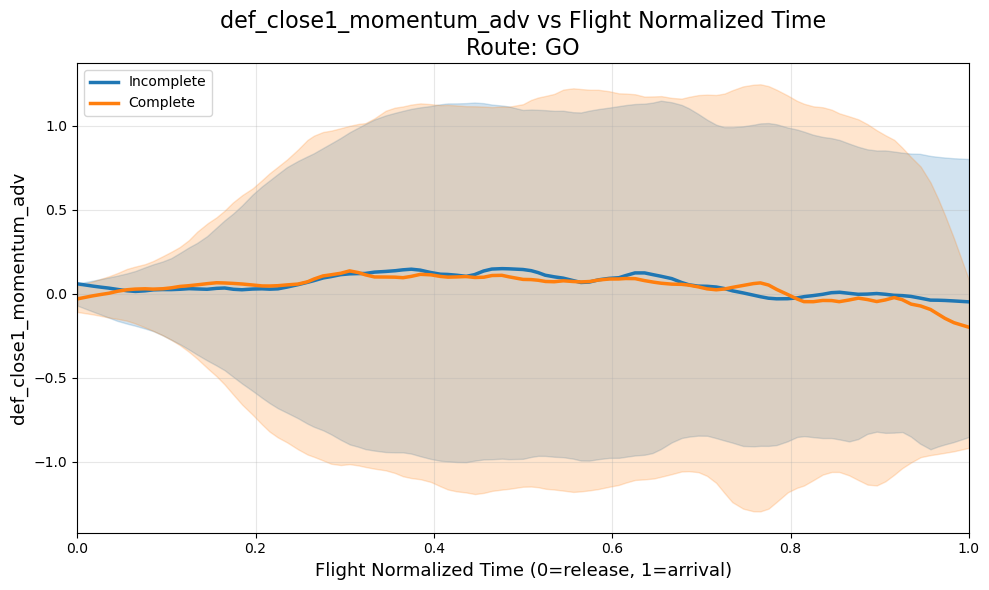

In [247]:
make_time_plot(data_adv, "def_close1_momentum_adv", route_type = "GO")

Remarks:
* In analyzing initial closest defender:
  * GO: Minimal difference until from like 0.9-1, we do see a decrease for completions
  * POST: Not much difference at all, completion line beneath incomplete...
  * CORNER: Not much difference at all till around 0.8, where completion under incomplete...
  * CROSS: Not much difference, but complete below incomplete... it seems that from around 0.1 to 0.8, if defender has advantage, complete...
  * IN: For completions, we see a decrease from 0.4 to 0.7, incomplete is marginal increase...
  * HITCH: Interesting, see advantage receiver up until 0.7, then goes adv def... I think what we see here is if we can get a big change from 0.6 to 0.7 (the break), it is a likely completion??
  * OUT: Similar to 0.2, from then on, completion indicated by a big change (decrease) from 0.25 to 0.4, which is likely the break!
  * WHEEL: Similar up to 0.2, and for completion, see a pretty legit decrease (break) from 0.2 to 0.35, and defender maintains advantage after trying to catch up?
  * SLANT: Very interesting behavior. Fairly similar up until 0.4, where for a completion, we see a break decrease from 0.4 to 0.65, where for incomplete, at about 0.55 to 0.6, we see a spike back toward receiver advantage...
  * FLAT: Big receiver advantage from 0.2 to 0.8

* Interesting behavior - almost like saying that if a defender is pursuing the ball at a higher rate then the receiver, it indicates that the defender is behind defensively...

Future Investigation:
* Look into whether there is merit to completion probability based on observed breaks
* For minimal difference statistics, this might just not be meaningful...

#### closing_speed_ball_adv
In individual form, measures a player's actual movement toward the ball, specifically how quickly they are closing the window between themselves and the ball. The advantage metric measures the difference between the targeted receiver's closing speed toward ball with a defender's closing speed toward ball...

In [267]:
data_adv['def_1_ball_dist'].corr(data_adv['def_close1_ball_dist'])

np.float64(1.0)

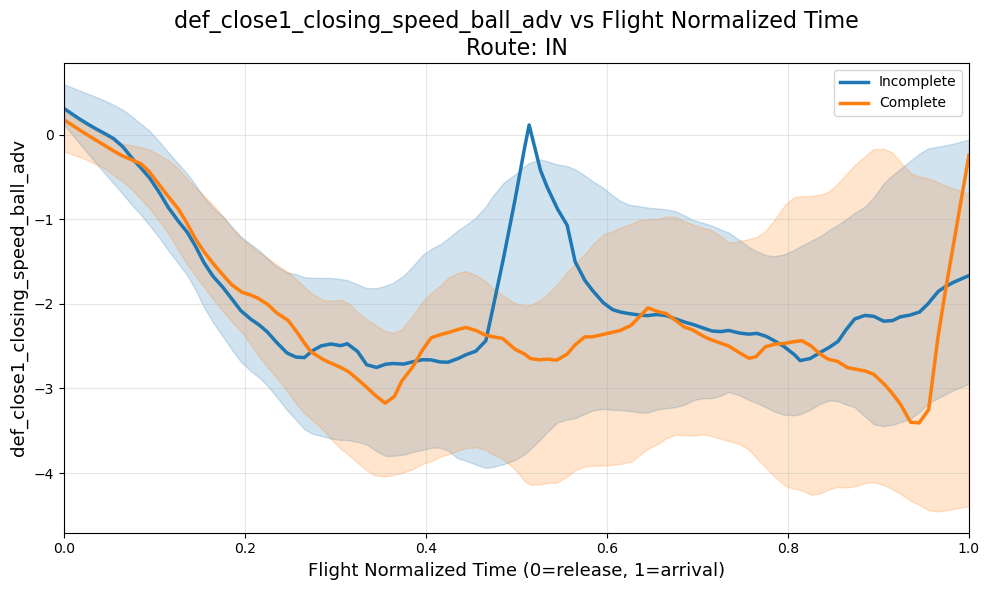

In [265]:
make_time_plot(data_adv, "def_close1_closing_speed_ball_adv", route_type = "IN")

Remarks:
* In analyzing initial closest defender:
  * GO: Minimal difference until from like 0.9-1, we do see a decrease for completions
  * POST: Not much difference at all, completion line beneath incomplete...
  * CORNER: Not much difference at all till around 0.8, where completion under incomplete...
  * CROSS: Not much difference, but complete below incomplete... it seems that from around 0.1 to 0.8, if defender has advantage, complete...
  * IN: For completions, we see a decrease from 0.4 to 0.7, incomplete is marginal increase...
  * HITCH: Interesting, see advantage receiver up until 0.7, then goes adv def... I think what we see here is if we can get a big change from 0.6 to 0.7 (the break), it is a likely completion??
  * OUT: Similar to 0.2, from then on, completion indicated by a big change (decrease) from 0.25 to 0.4, which is likely the break!
  * WHEEL: Similar up to 0.2, and for completion, see a pretty legit decrease (break) from 0.2 to 0.35, and defender maintains advantage after trying to catch up?
  * SLANT: Very interesting behavior. Fairly similar up until 0.4, where for a completion, we see a break decrease from 0.4 to 0.65, where for incomplete, at about 0.55 to 0.6, we see a spike back toward receiver advantage...
  * FLAT: Big receiver advantage from 0.2 to 0.8

* Interesting behavior - almost like saying that if a defender is pursuing the ball at a higher rate then the receiver, it indicates that the defender is behind defensively...

Future Investigation:
* Look into whether there is merit to completion probability based on observed breaks
* For minimal difference statistics, this might just not be meaningful...

In [77]:
wide_data['route_of_targeted_receiver'].value_counts()

route_of_targeted_receiver
GO        52406
POST      23024
CORNER    17944
CROSS     12176
IN         5550
HITCH      4554
OUT        2968
WHEEL      1168
SLANT       636
FLAT        474
SCREEN      110
Name: count, dtype: int64

In [119]:
complete_go = wide_data[(wide_data['complete'] == 1) &
          (wide_data['route_of_targeted_receiver'] == 'GO')]

In [120]:
unique_complete_go_pairs = complete_go[['game_id', 'play_id']].drop_duplicates()

In [121]:
unique_complete_go_pairs.head()

,game_id,play_id
292,2023090700,1679
978,2023091001,4018
1394,2023091003,410
1562,2023091003,2608
1676,2023091004,365


In [310]:
filt = data_adv[(data_adv['game_id'] == 2023090700) & (data_adv['play_id'] == 1679)][['game_id', 'play_id', 'frame_id', 'to_release']]

In [311]:
filt.head(60)

,game_id,play_id,frame_id,to_release
292,2023090700,1679,1,before
293,2023090700,1679,2,before
294,2023090700,1679,3,before
295,2023090700,1679,4,before
296,2023090700,1679,5,before
297,2023090700,1679,6,before
298,2023090700,1679,7,before
299,2023090700,1679,8,before
300,2023090700,1679,9,before
301,2023090700,1679,10,before


In [256]:
filt = data_adv[(data_adv['game_id'] == 2023090700) & (data_adv['play_id'] == 1679)][['frame_id', 'to_release', 'frames_till_event', 'flight_normalized_time', 'def_1_t_to_ball', 'def_1_closing_speed_ball_adv']]

In [257]:
filt.head(60)

,frame_id,to_release,frames_till_event,flight_normalized_time,def_1_t_to_ball,def_1_closing_speed_ball_adv
292,1,before,30.0,0.000000,35.799293,NaN
293,2,before,29.0,0.033333,42.805695,0.121361
294,3,before,28.0,0.066667,74.525167,0.177918
295,4,before,27.0,0.100000,65.106536,0.115738
296,5,before,26.0,0.133333,32.514405,-0.494824
297,6,before,25.0,0.166667,20.610452,-0.974553
298,7,before,24.0,0.200000,14.243058,-1.751666
299,8,before,23.0,0.233333,11.153284,-2.344525
300,9,before,22.0,0.266667,9.225791,-3.084845
301,10,before,21.0,0.300000,7.537044,-3.555745


In [91]:
def plot_play_distances(data, game_id, play_id):
    play = data[(data['game_id'] == game_id) & (data['play_id'] == play_id)]
    play = play.sort_values("frame_id").reset_index(drop=True)

    def_cols = [col for col in data.columns if col.startswith("def_")]

    def_ball_cols = [c for c in def_cols if c.endswith("ball_dist")]
    def_rec_dist_cols = [c for c in def_cols if c.endswith("_dist") and not c.endswith("ball_dist")]

    plt.figure(figsize=(12, 7))

    plt.plot(
        play["frame_id"],
        play["tgt_rec_ball_dist"],
        linewidth = 2,
        label = "Receiver Ball Dist",
    )

    for col in def_ball_cols:
        plt.plot(play["frame_id"], play[col], linestyle="--", label=col)

    for col in def_rec_dist_cols:
        plt.plot(play["frame_id"], play[col], linestyle=":", label=col)

    plt.xlabel("Frame")
    plt.ylabel("Distance (yards)")
    plt.title(f"Play Distance Over Time\nGame {game_id}, Play {play_id}")
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.0))
    plt.tight_layout()
    plt.show()

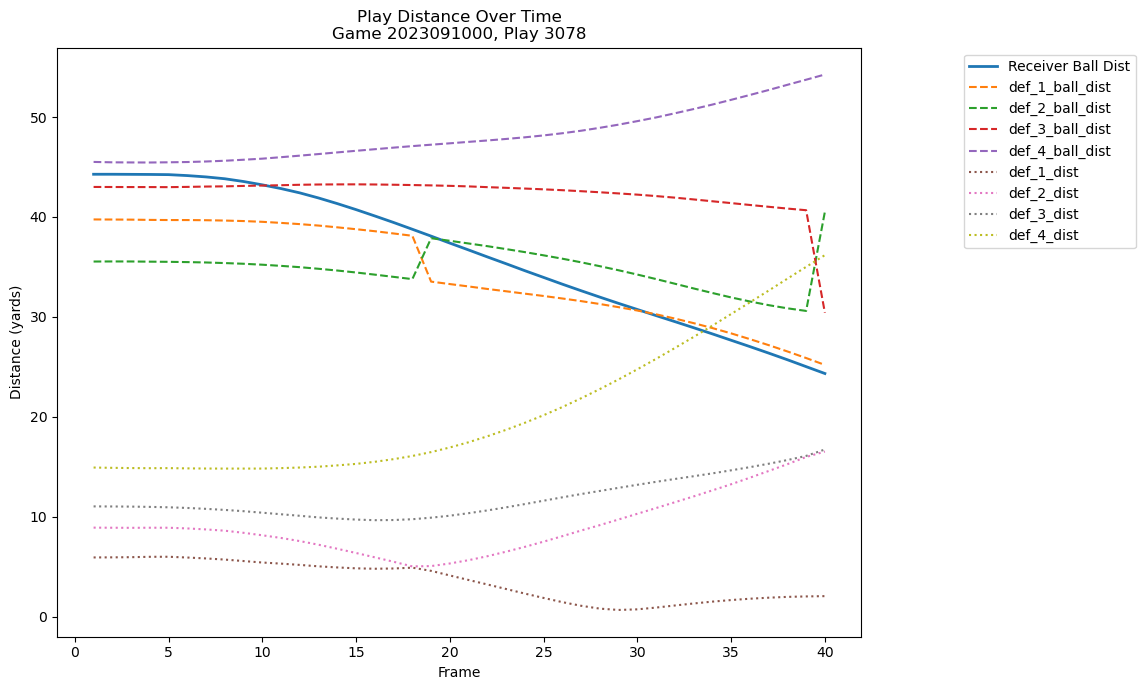

In [98]:
plot_play_distances(wide_data, 2023091000, 3078)